### **EX NO 5 - IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION**

***- SREENIDHI S (24BAD114)***

**AIM**

To implement a Recurrent Neural Network (RNN) for text generation and evaluate its ability to generate meaningful text by predicting the next word in a sequence.

**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow or keras or PyTorch

•	Google Colab

•	GitHub

•	Numpy

•	Matplotlib


**PROCEDURE**

**TASK A: DATASET PREPARATION**

Perform the following tasks:

•	Load the Tiny Shakespeare dataset from Hugging Face.

•	Explore the dataset and examine the text samples.

•	Convert the text into lowercase (if required).

•	Tokenize the text into individual words.

•	Build a vocabulary and assign a unique integer index to each word.

•	Generate input sequences for next-word prediction.

•	Apply sequence padding to obtain inputs of equal length.

•	Split the prepared sequences into training and validation datasets.


In [1]:
# Install required libraries
!pip install -q datasets tensorflow numpy matplotlib

In [6]:
# Student details
print("SREENIDHI S (24BAD114)")

# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import requests

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

SREENIDHI S (24BAD114)
Libraries imported successfully!


In [7]:
# Import requests library
import requests

# TASK A: Load Tiny Shakespeare Dataset

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
response.raise_for_status()

text = response.text

print("Dataset loaded successfully!")
print("Number of characters:", len(text))

Dataset loaded successfully!
Number of characters: 1115394


In [8]:
# TASK A: Explore the Dataset

print("--- DATASET INFORMATION ---")
print("Dataset Name: Tiny Shakespeare")
print("Text Type: Shakespeare plays")
print("Number of Characters:", len(text))

print("\n--- FIRST 1000 CHARACTERS ---\n")
print(text[:1000])

--- DATASET INFORMATION ---
Dataset Name: Tiny Shakespeare
Text Type: Shakespeare plays
Number of Characters: 1115394

--- FIRST 1000 CHARACTERS ---

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a 

In [9]:
# Convert text into lowercase

text = text.lower()

print("--- LOWERCASE TEXT SAMPLE ---\n")
print(text[:500])

--- LOWERCASE TEXT SAMPLE ---

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [10]:
# TASK A: Tokenization and Vocabulary Creation

# Create a word-level tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

# Fit tokenizer on the text
tokenizer.fit_on_texts([text])

# Convert text into integer sequences
word_sequences = tokenizer.texts_to_sequences([text])[0]

# Calculate vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("--- TOKENIZATION RESULTS ---")
print("Total Tokens:", len(word_sequences))
print("Vocabulary Size:", vocab_size)

print("\n--- VOCABULARY SAMPLE ---")
for word, index in list(tokenizer.word_index.items())[:20]:
    print(word, ":", index)

--- TOKENIZATION RESULTS ---
Total Tokens: 204089
Vocabulary Size: 12634

--- VOCABULARY SAMPLE ---
<OOV> : 1
the : 2
and : 3
to : 4
i : 5
of : 6
you : 7
my : 8
a : 9
that : 10
in : 11
is : 12
not : 13
for : 14
with : 15
me : 16
it : 17
be : 18
your : 19
his : 20


In [11]:
# TASK A: Generate Input and Target Sequences

# Define the input sequence length
sequence_length = 10

X = []
y = []

# Generate sequences
for i in range(len(word_sequences) - sequence_length):
    X.append(word_sequences[i:i + sequence_length])
    y.append(word_sequences[i + sequence_length])

# Convert lists into NumPy arrays
X = np.array(X)
y = np.array(y)

print("--- SEQUENCE GENERATION ---")
print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

print("\n--- SAMPLE INPUT AND TARGET ---")
print("Input Tokens:", X[0])
print("Target Token:", y[0])

--- SEQUENCE GENERATION ---
Input Shape: (204079, 10)
Target Shape: (204079,)

--- SAMPLE INPUT AND TARGET ---
Input Tokens: [ 89 270 140  36 970 144 669 128  16 103]
Target Token: 34


In [12]:
# TASK A: Apply Sequence Padding

X_padded = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre",
    truncating="pre"
)

print("--- PADDING RESULTS ---")
print("Padded Input Shape:", X_padded.shape)
print("First Padded Sequence:", X_padded[0])

--- PADDING RESULTS ---
Padded Input Shape: (204079, 10)
First Padded Sequence: [ 89 270 140  36 970 144 669 128  16 103]


In [13]:
# TASK A: Split Dataset into Training and Validation Sets

X_train, X_val, y_train, y_val = train_test_split(
    X_padded,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

print("--- DATASET SPLIT ---")
print("Training Input Shape:", X_train.shape)
print("Validation Input Shape:", X_val.shape)
print("Training Target Shape:", y_train.shape)
print("Validation Target Shape:", y_val.shape)

--- DATASET SPLIT ---
Training Input Shape: (163263, 10)
Validation Input Shape: (40816, 10)
Training Target Shape: (163263,)
Validation Target Shape: (40816,)


In [14]:
# Display a sample sequence in word form

index_word = {index: word for word, index in tokenizer.word_index.items()}

print("--- SAMPLE SEQUENCE IN WORD FORM ---")

sample_input_words = [
    index_word.get(token, "<PAD>")
    for token in X_train[0]
]

sample_target_word = index_word.get(y_train[0], "<UNKNOWN>")

print("Input Words:", sample_input_words)
print("Target Word:", sample_target_word)

--- SAMPLE SEQUENCE IN WORD FORM ---
Input Words: ['first', 'citizen', 'before', 'we', 'proceed', 'any', 'further', 'hear', 'me', 'speak']
Target Word: all


In [15]:
# TASK A: Final Summary

print("=" * 55)
print("SREENIDHI S (24BAD114)")
print("TASK A: DATASET PREPARATION COMPLETED")
print("=" * 55)

print("Dataset: Tiny Shakespeare")
print("Total Characters:", len(text))
print("Total Tokens:", len(word_sequences))
print("Vocabulary Size:", vocab_size)
print("Sequence Length:", sequence_length)
print("Total Sequences:", len(X_padded))
print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Training Input Shape:", X_train.shape)
print("Validation Input Shape:", X_val.shape)

print("=" * 55)

SREENIDHI S (24BAD114)
TASK A: DATASET PREPARATION COMPLETED
Dataset: Tiny Shakespeare
Total Characters: 1115394
Total Tokens: 204089
Vocabulary Size: 12634
Sequence Length: 10
Total Sequences: 204079
Training Samples: 163263
Validation Samples: 40816
Training Input Shape: (163263, 10)
Validation Input Shape: (40816, 10)


**TASK B: IMPLEMENTING THE RNN MODEL**

Perform the following tasks:

•	Create an Embedding layer to convert words into dense vector representations.

•	Add a Simple RNN layer to learn sequential dependencies in the text.

•	Add a Dense output layer with Softmax activation for next-word prediction.

•	Compile the model using an appropriate optimizer and loss function.

•	Display the model architecture and summary.


In [16]:
# TASK B: Import Required Libraries

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("Required libraries imported successfully!")

Required libraries imported successfully!


In [17]:
# Define model parameters

embedding_dim = 128
rnn_units = 128

print("Vocabulary Size:", vocab_size)
print("Sequence Length:", sequence_length)
print("Embedding Dimension:", embedding_dim)
print("RNN Units:", rnn_units)

Vocabulary Size: 12634
Sequence Length: 10
Embedding Dimension: 128
RNN Units: 128


In [18]:
# TASK B: Create the RNN Model

model = Sequential([
    # Embedding layer
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=sequence_length
    ),

    # Simple RNN layer
    SimpleRNN(
        rnn_units,
        activation="tanh"
    ),

    # Dense output layer with Softmax
    Dense(
        vocab_size,
        activation="softmax"
    )
])

print("RNN model created successfully!")

RNN model created successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
# Compile the RNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [20]:
# Display model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Display model configuration

print("--- MODEL CONFIGURATION ---")
print("Model Type: Sequential RNN")
print("Embedding Dimension:", embedding_dim)
print("RNN Units:", rnn_units)
print("Output Classes:", vocab_size)
print("Optimizer: Adam")
print("Loss Function: Sparse Categorical Crossentropy")
print("Activation Function: Softmax")

--- MODEL CONFIGURATION ---
Model Type: Sequential RNN
Embedding Dimension: 128
RNN Units: 128
Output Classes: 12634
Optimizer: Adam
Loss Function: Sparse Categorical Crossentropy
Activation Function: Softmax


In [22]:
# TASK B: Final Summary

print("=" * 55)
print("SREENIDHI S (24BAD114)")
print("TASK B: RNN MODEL IMPLEMENTATION COMPLETED")
print("=" * 55)

print("Embedding Layer: Created")
print("Simple RNN Layer: Created")
print("Dense Output Layer: Created")
print("Softmax Activation: Applied")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy")
print("Model Compilation: Successful")

print("=" * 55)

SREENIDHI S (24BAD114)
TASK B: RNN MODEL IMPLEMENTATION COMPLETED
Embedding Layer: Created
Simple RNN Layer: Created
Dense Output Layer: Created
Softmax Activation: Applied
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Model Compilation: Successful


**TASK C: RNN MODEL TRAINING AND PERFORMANCE EVALUATION**

Perform the following tasks:

•	Train the RNN model using the prepared training dataset.

•	Validate the model using the validation dataset.

•	Record:

o	Training accuracy

o	Validation accuracy

o	Training loss

o	Validation loss

•	Visualize:

o	Accuracy vs. Epoch

o	Loss vs. Epoch


In [23]:
# TASK C: Set Training Parameters

epochs = 10
batch_size = 128

print("Training Parameters")
print("Epochs:", epochs)
print("Batch Size:", batch_size)

Training Parameters
Epochs: 10
Batch Size: 128


In [24]:
# TASK C: Train the RNN Model

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 78s 60ms/step - accuracy: 0.0465 - loss: 6.7354 - val_accuracy: 0.0689 - val_loss: 6.7432
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 79s 58ms/step - accuracy: 0.0842 - loss: 6.0520 - val_accuracy: 0.0788 - val_loss: 6.6891
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.0989 - loss: 5.6985 - val_accuracy: 0.0816 - val_loss: 6.7645
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 74s 58ms/step - accuracy: 0.1109 - loss: 5.4093 - val_accuracy: 0.0822 - val_loss: 6.8733
Epoch 5/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 74s 58ms/step - accuracy: 0.1233 - loss: 5.1470 - val_accuracy: 0.0808 - val_loss: 7.0041
Epoch 6/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 0.1393 - loss: 4.9006 - val_accuracy: 0.0786 - val_loss: 7.1411
Epoch 7/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.1600 - loss: 4.6697 - val_accuracy: 0.0749 - val_loss: 7.2830
Epoch 8/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 0.1848 -

In [25]:
# Evaluate the model on validation data

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("--- FINAL VALIDATION RESULTS ---")
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

--- FINAL VALIDATION RESULTS ---
Validation Loss: 7.691666603088379
Validation Accuracy: 0.06720403581857681


In [26]:
# TASK C: Record Training and Validation Metrics

train_accuracy = history.history["accuracy"]
val_accuracy_history = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss_history = history.history["val_loss"]

print("--- TRAINING METRICS ---")

for epoch in range(len(train_accuracy)):
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Accuracy: {train_accuracy[epoch]:.4f}")
    print(f"  Validation Accuracy: {val_accuracy_history[epoch]:.4f}")
    print(f"  Training Loss: {train_loss[epoch]:.4f}")
    print(f"  Validation Loss: {val_loss_history[epoch]:.4f}")
    print()

--- TRAINING METRICS ---
Epoch 1:
  Training Accuracy: 0.0465
  Validation Accuracy: 0.0689
  Training Loss: 6.7354
  Validation Loss: 6.7432

Epoch 2:
  Training Accuracy: 0.0842
  Validation Accuracy: 0.0788
  Training Loss: 6.0520
  Validation Loss: 6.6891

Epoch 3:
  Training Accuracy: 0.0989
  Validation Accuracy: 0.0816
  Training Loss: 5.6985
  Validation Loss: 6.7645

Epoch 4:
  Training Accuracy: 0.1109
  Validation Accuracy: 0.0822
  Training Loss: 5.4093
  Validation Loss: 6.8733

Epoch 5:
  Training Accuracy: 0.1233
  Validation Accuracy: 0.0808
  Training Loss: 5.1470
  Validation Loss: 7.0041

Epoch 6:
  Training Accuracy: 0.1393
  Validation Accuracy: 0.0786
  Training Loss: 4.9006
  Validation Loss: 7.1411

Epoch 7:
  Training Accuracy: 0.1600
  Validation Accuracy: 0.0749
  Training Loss: 4.6697
  Validation Loss: 7.2830

Epoch 8:
  Training Accuracy: 0.1848
  Validation Accuracy: 0.0721
  Training Loss: 4.4562
  Validation Loss: 7.4249

Epoch 9:
  Training Accuracy: 0

In [27]:
# Display final training and validation metrics

print("=" * 60)
print("SREENIDHI S (24BAD114)")
print("FINAL TRAINING AND VALIDATION METRICS")
print("=" * 60)

print(f"Final Training Accuracy:   {train_accuracy[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracy_history[-1]:.4f}")
print(f"Final Training Loss:       {train_loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss_history[-1]:.4f}")

print("=" * 60)

SREENIDHI S (24BAD114)
FINAL TRAINING AND VALIDATION METRICS
Final Training Accuracy:   0.2302
Final Validation Accuracy: 0.0672
Final Training Loss:       4.1114
Final Validation Loss:     7.6917


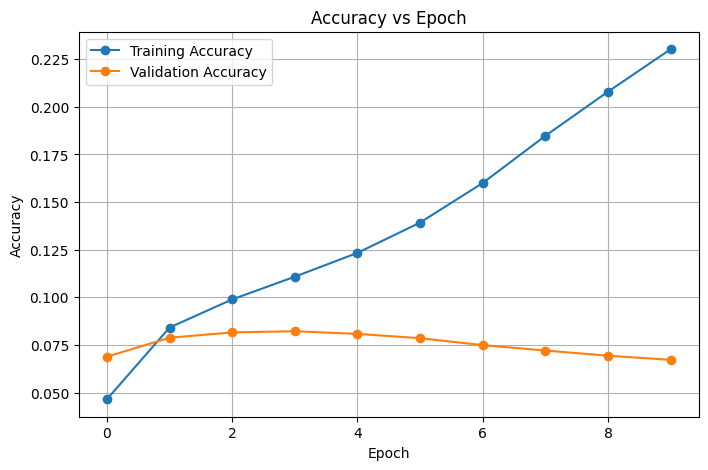

In [28]:
# TASK C: Accuracy vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    marker="o"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    marker="o"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

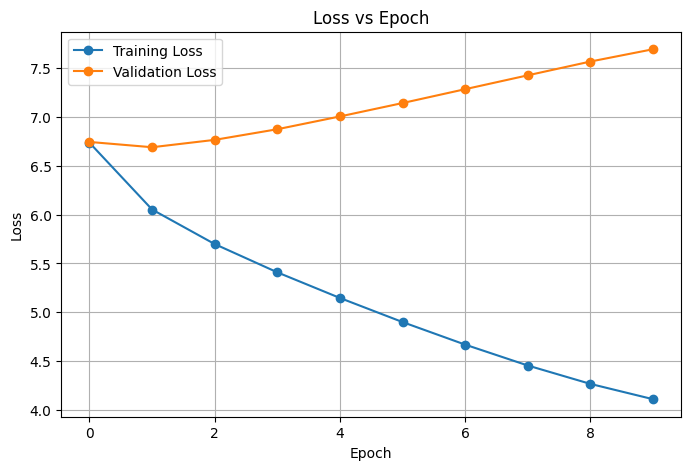

In [29]:
# TASK C: Loss vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    marker="o"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    marker="o"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# TASK C: Final Summary

print("=" * 60)
print("SREENIDHI S (24BAD114)")
print("TASK C: RNN TRAINING AND PERFORMANCE EVALUATION COMPLETED")
print("=" * 60)

print("Model Training: Completed")
print("Model Validation: Completed")
print("Training Accuracy: Recorded")
print("Validation Accuracy: Recorded")
print("Training Loss: Recorded")
print("Validation Loss: Recorded")
print("Accuracy Graph: Displayed")
print("Loss Graph: Displayed")

print("=" * 60)

SREENIDHI S (24BAD114)
TASK C: RNN TRAINING AND PERFORMANCE EVALUATION COMPLETED
Model Training: Completed
Model Validation: Completed
Training Accuracy: Recorded
Validation Accuracy: Recorded
Training Loss: Recorded
Validation Loss: Recorded
Accuracy Graph: Displayed
Loss Graph: Displayed


**TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT**

Perform the following tasks:

•	Provide a seed word or sentence as input to the trained model.

•	Generate text by repeatedly predicting the next word in the sequence.

•	Produce multiple text samples using different seed inputs.

•	Compare the generated text for coherence and contextual relevance.

•	Document the observations and upload the notebook to GitHub.


In [31]:
# TASK D: Import Required Libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Required libraries imported successfully!")

Required libraries imported successfully!


In [32]:
# TASK D: Define Text Generation Function

def generate_text(seed_text, next_words=20):
    """
    Generate text using the trained RNN model.

    seed_text: Starting word or sentence
    next_words: Number of words to generate
    """

    generated_text = seed_text.lower()

    for _ in range(next_words):

        # Convert current text into integer tokens
        token_list = tokenizer.texts_to_sequences([generated_text])[0]

        # Keep only the last sequence_length words
        token_list = token_list[-sequence_length:]

        # Apply padding
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict probabilities for the next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        # Select the word with the highest probability
        predicted_index = np.argmax(predicted_probabilities, axis=-1)[0]

        # Convert predicted index back to a word
        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        # Stop if no word is found
        if output_word == "":
            break

        # Append predicted word to generated text
        generated_text += " " + output_word

    return generated_text

In [33]:
# TASK D: Generate Text from a Seed Sentence

seed_text = "to be or not to be"

generated_text = generate_text(
    seed_text,
    next_words=20
)

print("--- GENERATED TEXT ---")
print(generated_text)

--- GENERATED TEXT ---
to be or not to be a thousand times i have a thousand times in two parts than i had heard it in the king of


In [34]:
# TASK D: Generate Multiple Text Samples

seed_inputs = [
    "to be or not to be",
    "the king",
    "my lord",
    "what is"
]

print("=" * 70)
print("SREENIDHI S (24BAD114)")
print("MULTIPLE GENERATED TEXT SAMPLES")
print("=" * 70)

for seed in seed_inputs:
    generated = generate_text(seed, next_words=15)

    print("\nSeed Text:", seed)
    print("Generated Text:", generated)
    print("-" * 70)

SREENIDHI S (24BAD114)
MULTIPLE GENERATED TEXT SAMPLES

Seed Text: to be or not to be
Generated Text: to be or not to be a thousand times i have a thousand times in two parts than i had heard
----------------------------------------------------------------------

Seed Text: the king
Generated Text: the king henry vi my lord king richard iii what is the matter in the world and
----------------------------------------------------------------------

Seed Text: my lord
Generated Text: my lord will't please you sir to me i am too much to the king of england
----------------------------------------------------------------------

Seed Text: what is
Generated Text: what is thy sword and i must not be it in your own good lord of you
----------------------------------------------------------------------


In [35]:
# TASK D: Compare Generated Text

results = []

for seed in seed_inputs:
    generated = generate_text(seed, next_words=15)

    results.append({
        "Seed": seed,
        "Generated Text": generated
    })

print("--- TEXT GENERATION COMPARISON ---\n")

for i, result in enumerate(results, start=1):
    print(f"Sample {i}")
    print("Seed:", result["Seed"])
    print("Generated:", result["Generated Text"])
    print()

--- TEXT GENERATION COMPARISON ---

Sample 1
Seed: to be or not to be
Generated: to be or not to be a thousand times i have a thousand times in two parts than i had heard

Sample 2
Seed: the king
Generated: the king henry vi my lord king richard iii what is the matter in the world and

Sample 3
Seed: my lord
Generated: my lord will't please you sir to me i am too much to the king of england

Sample 4
Seed: what is
Generated: what is thy sword and i must not be it in your own good lord of you



In [36]:
# TASK D: Observations

print("=" * 65)
print("SREENIDHI S (24BAD114)")
print("OBSERVATIONS")
print("=" * 65)

print("1. The RNN generated text by predicting one word at a time.")
print("2. Different seed sentences produced different generated outputs.")
print("3. The generated text showed some learned word patterns from the dataset.")
print("4. The coherence and contextual relevance varied depending on the seed.")
print("5. The model may produce repetitive or grammatically incorrect text.")
print("6. More training and suitable sequence lengths may improve generation quality.")

print("=" * 65)

SREENIDHI S (24BAD114)
OBSERVATIONS
1. The RNN generated text by predicting one word at a time.
2. Different seed sentences produced different generated outputs.
3. The generated text showed some learned word patterns from the dataset.
4. The coherence and contextual relevance varied depending on the seed.
5. The model may produce repetitive or grammatically incorrect text.
6. More training and suitable sequence lengths may improve generation quality.


In [37]:
# TASK D: Final Summary

print("=" * 65)
print("SREENIDHI S (24BAD114)")
print("TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT COMPLETED")
print("=" * 65)

print("Seed Text Provided: Yes")
print("Next-Word Prediction: Completed")
print("Multiple Text Samples: Generated")
print("Generated Text Comparison: Completed")
print("Observations: Documented")
print("Notebook: Ready for GitHub Upload")

print("=" * 65)

SREENIDHI S (24BAD114)
TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT COMPLETED
Seed Text Provided: Yes
Next-Word Prediction: Completed
Multiple Text Samples: Generated
Generated Text Comparison: Completed
Observations: Documented
Notebook: Ready for GitHub Upload
